# Stochastic Gradient Descent vs. Adam Estimation Momentum

**Imports**

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torch import nn


**Datensetz laden und einheitliche Bildtransformtion**

In [2]:
transformation_pipeline = v2.Compose([
    v2.Resize((64, 64)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), #Bringt alle Bilder auf eine ähnliche Farbskala (Werte nach ImageNet standard gewählt)
])

weather_dataset = datasets.ImageFolder(root=r'C:\Users\demyi\Desktop\UNI\KI\KIP\KIPraktikum\3. Termin\weather_data', transform=transformation_pipeline)

**Datensatz in trainings, validierungs und test Submengen aufteilen und Präperation von batches für das neuronale Netz**

In [3]:
train_weather_dataset, validate_weather_dataset, test_weather_dataset = torch.utils.data.random_split(weather_dataset, [0.7, 0.15, 0.15])

train_weather_dataloader = DataLoader(train_weather_dataset, batch_size=32, shuffle=True)
validate_weather_dataloader = DataLoader(validate_weather_dataset, batch_size=32, shuffle=False)
test_weather_dataloader = DataLoader(test_weather_dataset, batch_size=32, shuffle=False)

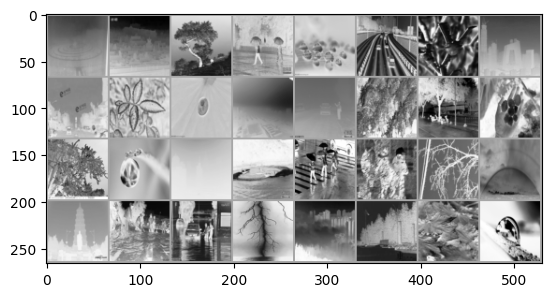

In [4]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_weather_dataloader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

# Neuronales Netz bauen (3 Farbkanäle (RGB))

In [5]:
input_size = 3 * 64 * 64
hidden_size = 512
output_size = 11



class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = nn.functional.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x


model = NeuralNetwork()
model_sgd = NeuralNetwork()
model_adam = NeuralNetwork()

model_adam.load_state_dict(model_sgd.state_dict())
print(model)
total_params = sum(p.numel() for p in model.parameters())
weights_count = sum(p.numel() for n, p in model.named_parameters() if 'weight' in n)
biases_count = sum(p.numel() for n, p in model.named_parameters() if 'bias' in n)
print(f"Total parameters: {total_params:,}")
print(f"Total Weight Elements: {weights_count:,}")
print(f"Total Bias Elements: {biases_count:,}")

loss_fn = nn.CrossEntropyLoss()

NeuralNetwork(
  (fc1): Linear(in_features=12288, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=11, bias=True)
)
Total parameters: 6,297,611
Total Weight Elements: 6,297,088
Total Bias Elements: 523


# Modell trainieren und validieren

In [6]:
training_loss_sgd = []
training_loss_adam = []
validate_loss_sgd = []
validate_loss_adam = []

epochs = 15
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.001)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)

for epoch in range(epochs):
    model_sgd.train()
    model_adam.train()

    epoch_train_loss_sgd = 0.0
    epoch_train_loss_adam = 0.0

    for x, y in train_weather_dataloader:
        #sgd
        optimizer_sgd.zero_grad()
        output_sgd = model_sgd(x) #Bilder übergeben
        loss_sgd = loss_fn(output_sgd, y)
        loss_sgd.backward()
        optimizer_sgd.step()
        epoch_train_loss_sgd += loss_sgd.item()

        #adam
        optimizer_adam.zero_grad()
        output_adam = model_adam(x)
        loss_adam = loss_fn(output_adam, y)
        loss_adam.backward()
        optimizer_adam.step()
        epoch_train_loss_adam += loss_adam.item()
    
    training_loss_sgd.append(epoch_train_loss_sgd / len(train_weather_dataloader))
    training_loss_adam.append(epoch_train_loss_adam / len(train_weather_dataloader))

    model_sgd.eval()
    model_adam.eval()

    epoch_val_loss_sgd = 0.0
    epoch_val_loss_adam = 0.0
    
    # torch.no_grad() deaktiviert die Gradientenberechnung spart Speicher und Zeit, wendet nur bereits erlerntes Wissen
    with torch.no_grad():
        for x, y in validate_weather_dataloader:
            # SGD Validierung
            output_sgd = model_sgd(x)
            loss_sgd = loss_fn(output_sgd, y)
            epoch_val_loss_sgd += loss_sgd.item()
            
            # Adam Validierung
            output_adam = model_adam(x)
            loss_adam = loss_fn(output_adam, y)
            epoch_val_loss_adam += loss_adam.item()
    
    validate_loss_sgd.append(epoch_val_loss_sgd / len(validate_weather_dataloader))
    validate_loss_adam.append(epoch_val_loss_adam / len(validate_weather_dataloader))

print("Training finished")


Training finished


# Ergebnis des Experiments

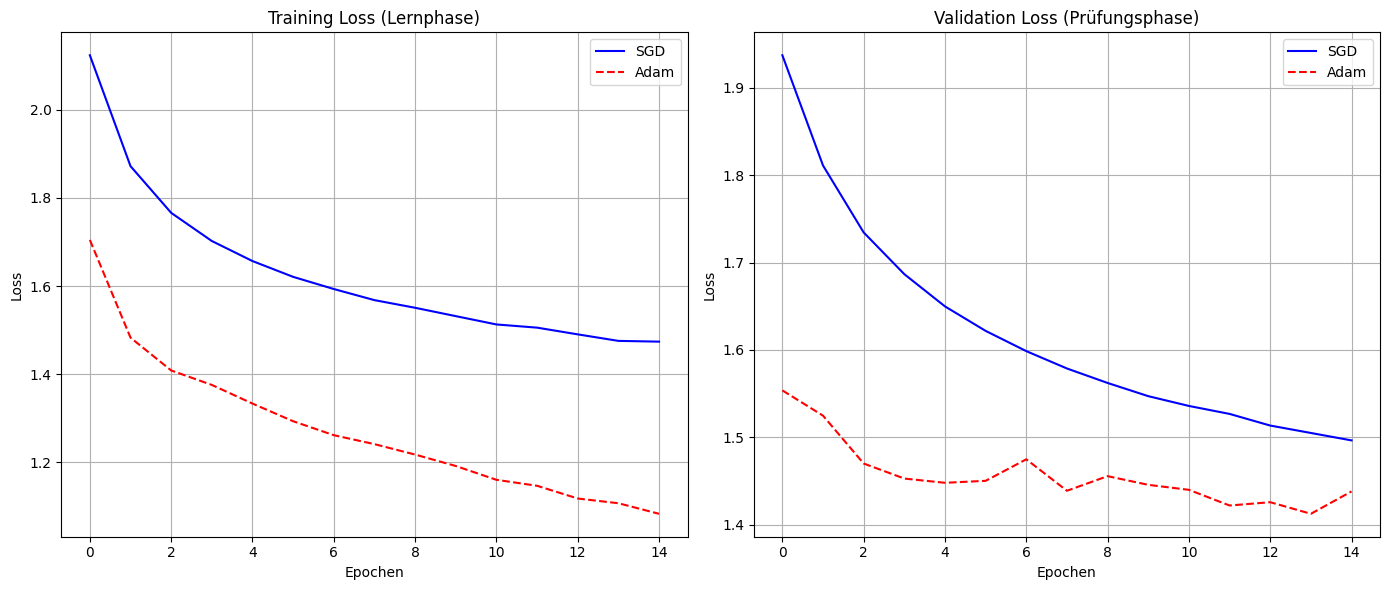

In [7]:
plt.figure(figsize=(14, 6))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(training_loss_sgd, label='SGD', color='blue')
plt.plot(training_loss_adam, label='Adam', color='red', linestyle='--')
plt.title('Training Loss (Lernphase)')
plt.xlabel('Epochen')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Validation Loss
plt.subplot(1, 2, 2)
plt.plot(validate_loss_sgd, label='SGD', color='blue')
plt.plot(validate_loss_adam, label='Adam', color='red', linestyle='--')
plt.title('Validation Loss (Prüfungsphase)')
plt.xlabel('Epochen')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Prüfung auf den Testdaten

In [8]:
#Testphase: Modelle in den Evaluierungsmodus setzen
model_sgd.eval()
model_adam.eval()

test_loss_sgd = 0.0
test_loss_adam = 0.0
correct_sgd = 0
correct_adam = 0
total_images = 0

with torch.no_grad():
    for x, y in test_weather_dataloader:
        
        #SGD Modell testen
        output_sgd = model_sgd(x)
        loss_sgd = loss_fn(output_sgd, y)
        test_loss_sgd += loss_sgd.item()
        
        #Vorhersage bestimmen (der höchste Wert in den 11 Klassen)
        _, predicted_sgd = torch.max(output_sgd, 1)
        correct_sgd += (predicted_sgd == y).sum().item()
        
        #Adam Modell testen
        output_adam = model_adam(x)
        loss_adam = loss_fn(output_adam, y)
        test_loss_adam += loss_adam.item()
        
        #Vorhersage bestimmen
        _, predicted_adam = torch.max(output_adam, 1)
        correct_adam += (predicted_adam == y).sum().item()
        
        total_images += y.size(0)

#Durchschnittliche Werte berechnen
avg_test_loss_sgd = test_loss_sgd / len(test_weather_dataloader)
avg_test_loss_adam = test_loss_adam / len(test_weather_dataloader)

accuracy_sgd = 100 * correct_sgd / total_images
accuracy_adam = 100 * correct_adam / total_images

print("Prüfung auf den Testdaten")
print(f"Modell SGD  -> Loss: {avg_test_loss_sgd:.4f} | Treffergenauigkeit: {accuracy_sgd:.2f}%")
print(f"Modell Adam -> Loss: {avg_test_loss_adam:.4f} | Treffergenauigkeit: {accuracy_adam:.2f}%")

Prüfung auf den Testdaten
Modell SGD  -> Loss: 1.5402 | Treffergenauigkeit: 49.37%
Modell Adam -> Loss: 1.5162 | Treffergenauigkeit: 53.84%


In [9]:
#11 Klassen aus ursprünglichen datensatz holen
classes = weather_dataset.classes

# Dictionaries für beide Modelle vorbereiten
correct_pred_sgd = {classname: 0 for classname in classes}
total_pred_sgd = {classname: 0 for classname in classes}

correct_pred_adam = {classname: 0 for classname in classes}
total_pred_adam = {classname: 0 for classname in classes}

with torch.no_grad():
    for x, y in test_weather_dataloader:
        
        #Vorhersagen für beide Modelle generieren
        outputs_sgd = model_sgd(x)
        _, predictions_sgd = torch.max(outputs_sgd, 1)
        
        outputs_adam = model_adam(x)
        _, predictions_adam = torch.max(outputs_adam, 1)
        
        #Jeden einzelnen Treffer aus dem Batch der richtigen Klasse zuordnen
        for label, prediction_sgd, prediction_adam in zip(y, predictions_sgd, predictions_adam):
            classname = classes[label.item()] # Echter Name der Klasse
            
            # Zählen für SGD
            if label == prediction_sgd:
                correct_pred_sgd[classname] += 1
            total_pred_sgd[classname] += 1
            
            # Zählen für Adam
            if label == prediction_adam:
                correct_pred_adam[classname] += 1
            total_pred_adam[classname] += 1

#Ergebnisse in einer sauberen Tabelle ausgeben
print("Klassenspezifische Genauigkeit (Testdaten)")
print(f"{'Wetter-Klasse':<18} | {'SGD':<10} | {'Adam':<10}")
print("-" * 46)

for classname in classes:
    #Berechnung der Prozente
    if total_pred_sgd[classname] > 0:
        acc_sgd = 100 * float(correct_pred_sgd[classname]) / total_pred_sgd[classname]
    else:
        acc_sgd = 0.0
        
    if total_pred_adam[classname] > 0:
        acc_adam = 100 * float(correct_pred_adam[classname]) / total_pred_adam[classname]
    else:
        acc_adam = 0.0
        
    print(f"{classname:<18} | {acc_sgd:>5.1f} %   | {acc_adam:>5.1f} %")

Klassenspezifische Genauigkeit (Testdaten)
Wetter-Klasse      | SGD        | Adam      
----------------------------------------------
dew                |  68.5 %   |  70.8 %
fogsmog            |  71.7 %   |  75.2 %
frost              |   2.9 %   |  20.3 %
glaze              |  11.2 %   |  35.7 %
hail               |  49.5 %   |  42.6 %
lightning          |  69.8 %   |  60.4 %
rain               |  23.5 %   |  27.9 %
rainbow            |   0.0 %   |  21.6 %
rime               |  75.8 %   |  66.5 %
sandstorm          |  65.5 %   |  64.6 %
snow               |  32.6 %   |  53.7 %
